## Import Library

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
print('Library berhasil di-import')

Library berhasil di-import


# Load dataset mentah

In [43]:
df = pd.read_csv('/content/train_raw.csv')
#Cek dimensi dan preview data
print(f'Dimensi dataset: {df.shape}')
print(f'Kolom: {list(df.columns)}')
df.head()

Dimensi dataset: (891, 12)
Kolom: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#Exploratory Data Analysis (EDA)

In [44]:
# === EDA 1: Informasi dasar dataset ===
print('=== INFO DATASET ===')
df.info()

# === EDA 2: Statistik deskriptif ===
print('\n=== STATISTIK DESKRIPTIF ===')
print(df.describe())

# === EDA 3: Cek missing values ===
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print(f'Persentase missing: {(df.isnull().sum()/len(df)*100).round(2)}')

# === EDA 4: Distribusi target variabel ===
print('\n=== DISTRIBUSI TARGET ===')
print(df['Survived'].value_counts())
print(df['Survived'].value_counts(normalize=True).round(3))

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== STATISTIK DESKRIPTIF ===
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.69911

#Visualisasi EDA

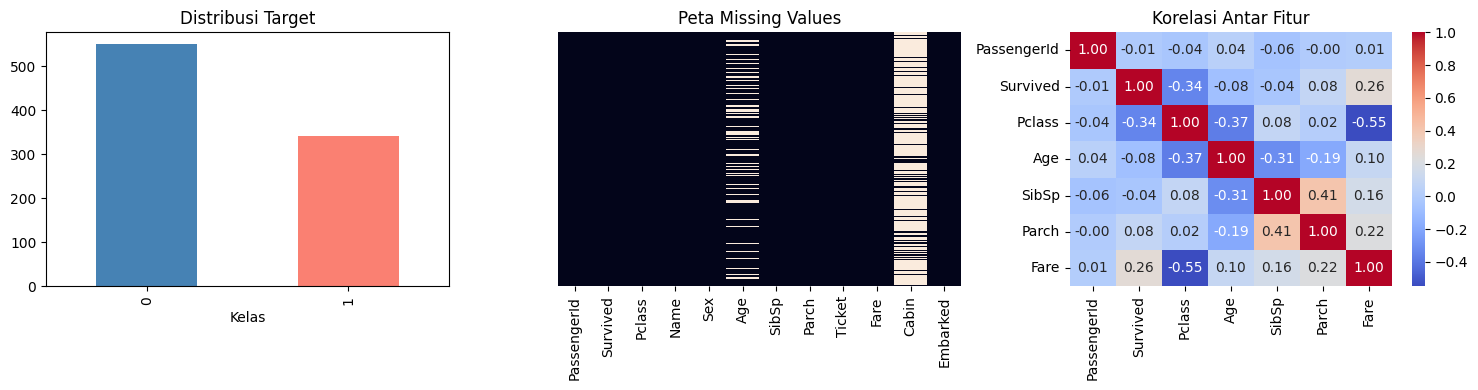

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Distribusi target
df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'])
axes[0].set_title('Distribusi Target')
axes[0].set_xlabel('Kelas')

# Plot 2: Missing values heatmap
sns.heatmap(df.isnull(), ax=axes[1], cbar=False, yticklabels=False)
axes[1].set_title('Peta Missing Values')

# Plot 3: Korelasi numerik
numeric_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[numeric_cols].corr(), ax=axes[2], annot=True, fmt='.2f', cmap='coolwarm')
axes[2].set_title('Korelasi Antar Fitur')

plt.tight_layout()
plt.savefig('eda_visualisasi.png', dpi=100, bbox_inches='tight')
plt.show()

# Preprocessing Data

In [46]:
# === STEP 1: Hapus duplikat ===
print(f'Data sebelum drop duplikat: {df.shape}')
df = df.drop_duplicates()
print(f'Data setelah drop duplikat: {df.shape}')

# === STEP 2: Handle missing values ===
# Imputasi kolom numerik dengan median
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'Survived' in numeric_cols:
    numeric_cols.remove('Survived')
if 'PassengerId' in numeric_cols:
    numeric_cols.remove('PassengerId')

imputer_num = SimpleImputer(strategy='median')
df[numeric_cols] = imputer_num.fit_transform(df[numeric_cols])

# Imputasi kolom kategorikal dengan modus
cat_cols = df.select_dtypes(include='object').columns.tolist()
imputer_cat = SimpleImputer(strategy='most_frequent')
if cat_cols: # Only impute if there are categorical columns
    df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

print(f'Missing setelah imputasi: {df.isnull().sum().sum()}')

# === STEP 3: Encoding variabel kategorikal ===
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f'Encoded: {col}')

# === STEP 4: Feature scaling ===
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print('Scaling selesai')

# === STEP 5: Simpan hasil preprocessing ===
df.to_csv('train_preprocessing.csv', index=False)
print(f'Dataset bersih disimpan. Shape: {df.shape}')

Data sebelum drop duplikat: (891, 12)
Data setelah drop duplikat: (891, 12)
Missing setelah imputasi: 0
Encoded: Name
Encoded: Sex
Encoded: Ticket
Encoded: Cabin
Encoded: Embarked
Scaling selesai
Dataset bersih disimpan. Shape: (891, 12)


In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import os, sys

def load_data(filepath: str) -> pd.DataFrame:
    #Load dataset dari file CSV
    if not os.path.exists(filepath):
        raise FileNotFoundError(f'File tidak ditemukan: {filepath}')
    df = pd.read_csv(filepath)
    print(f'[LOAD] Data berhasil dimuat. Shape: {df.shape}')
    return df

def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    #Hapus baris duplikat
    before = len(df)
    df = df.drop_duplicates()
    print(f'[DEDUP] Hapus {before - len(df)} duplikat. Sisa: {len(df)} baris')
    return df

def handle_missing(df: pd.DataFrame) -> pd.DataFrame:
    #Imputasi missing values
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    # Exclude target variable and PassengerId from imputation and scaling
    if 'Survived' in numeric_cols:
        numeric_cols.remove('Survived')
    if 'PassengerId' in numeric_cols:
        numeric_cols.remove('PassengerId')

    df[numeric_cols] = SimpleImputer(strategy='median').fit_transform(df[numeric_cols])
    if cat_cols:
        df[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[cat_cols])
    print(f'[IMPUTE] Missing setelah imputasi: {df.isnull().sum().sum()}')
    return df

def encode_categorical(df: pd.DataFrame) -> pd.DataFrame:
    #Label encoding untuk kolom kategorikal
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col])
    print(f'[ENCODE] Encoded {len(cat_cols)} kolom kategorik')
    return df

def scale_features(df: pd.DataFrame) -> pd.DataFrame:
    #StandardScaler pada fitur numerik
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    # Exclude target variable and PassengerId from imputation and scaling
    if 'Survived' in numeric_cols:
        numeric_cols.remove('Survived')
    if 'PassengerId' in numeric_cols:
        numeric_cols.remove('PassengerId')
    df[numeric_cols] = StandardScaler().fit_transform(df[numeric_cols])
    print(f'[SCALE] Scaling selesai pada {len(numeric_cols)} kolom)')
    return df

def run_preprocessing(input_path: str, output_path: str):
    """Fungsi utama: jalankan seluruh pipeline preprocessing."""
    print('='*50)
    print('MULAI PREPROCESSING OTOMATIS')
    print('='*50)

    df = load_data(input_path)
    df = remove_duplicates(df)
    df = handle_missing(df)
    df = encode_categorical(df)
    df = scale_features(df)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    df.to_csv(output_path, index=False)
    print(f'\n[DONE] Data bersih disimpan ke: {output_path}')
    print(f'[DONE] Shape akhir: {df.shape}')
    return df

if __name__ == '__main__':
    INPUT = "/content/train_raw.csv"
    OUTPUT = "preprocessing/train_preprocessing.csv"
    run_preprocessing(INPUT, OUTPUT)

MULAI PREPROCESSING OTOMATIS
[LOAD] Data berhasil dimuat. Shape: (891, 12)
[DEDUP] Hapus 0 duplikat. Sisa: 891 baris
[IMPUTE] Missing setelah imputasi: 0
[ENCODE] Encoded 5 kolom kategorik
[SCALE] Scaling selesai pada 10 kolom)

[DONE] Data bersih disimpan ke: preprocessing/train_preprocessing.csv
[DONE] Shape akhir: (891, 12)
